Section 1 — Load Dataset

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/dataset.csv")

print(df.shape)
df.head()

(298450, 24)


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,...,26.0,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,...,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


Section 2 — Dataset Overview

In [6]:
print(df.info())

display(df.sample(5))

<class 'pandas.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            298450 non-null  str    
 1   latitude                      298450 non-null  float64
 2   longitude                     298450 non-null  float64
 3   location                      295409 non-null  str    
 4   vehicle_number                298450 non-null  str    
 5   vehicle_type                  298450 non-null  str    
 6   description                   0 non-null       float64
 7   violation_type                298450 non-null  str    
 8   offence_code                  298450 non-null  str    
 9   created_datetime              298450 non-null  str    
 10  closed_datetime               0 non-null       float64
 11  modified_datetime             298450 non-null  str    
 12  device_id                     298450 non-null  str    


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
176907,FKID176907,12.976141,77.580918,"Y Ramachandra Road, Maharani College Junction,...",FKN00GL146033,CAR,NaN,"[""WRONG PARKING""]",[112],2023-12-12 23:19:46+00,...,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL146033,CAR,approved,2023-12-20 03:59:12.985+00
136335,FKID136335,12.887040,77.640943,"Chikka Begur Main Road, Polisappa Layout, Sing...",FKN00GL113620,LORRY/GOODS VEHICLE,NaN,"[""WRONG PARKING""]",[112],2023-12-03 22:24:46+00,...,44.0,Hulimavu,True,No Junction,NaN,NaN,FKN00GL113620,LORRY/GOODS VEHICLE,approved,2023-12-04 22:58:50.81+00
41400,FKID041400,12.982343,77.606317,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",FKN00GL37354,CAR,NaN,"[""WRONG PARKING""]",[112],2024-04-01 06:22:46+00,...,16.0,Shivajinagar,False,BTP051 - Safina Plaza Junction,NaN,NaN,NaN,NaN,NaN,NaN
293059,FKID293059,12.973495,77.551284,"1st Cross Road, Mallige Thotta, Cholurpalya, B...",FKN00GL229412,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-21 05:47:46+00,...,29.0,Magadi Road,False,"BTP070 - Cholurpalya Junction, Magadi Road",NaN,NaN,NaN,NaN,NaN,NaN
178669,FKID178669,12.936474,77.692469,"Outer Ring Road, Salarpuria Sattva Premia, Kad...",FKN00GL28010,MAXI-CAB,NaN,"[""PARKING IN A MAIN ROAD"",""WRONG PARKING""]","[107,112]",2023-12-12 23:48:46+00,...,13.0,HAL Old Airport,True,No Junction,NaN,NaN,FKN00GL28010,MAXI-CAB,approved,2023-12-16 05:16:37.524+00


Section 3 — Missing Value Analysis

In [7]:
nulls = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": round(df.isna().mean()*100,2)
})

nulls.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
description,298450,100.00
closed_datetime,298450,100.00
action_taken_timestamp,298450,100.00
data_sent_to_scita_timestamp,256289,85.87
updated_vehicle_type,125254,41.97
validation_timestamp,125254,41.97
validation_status,125254,41.97
updated_vehicle_number,125254,41.97
center_code,11260,3.77
location,3041,1.02


In [8]:
important_cols = [
    "action_taken_timestamp",
    "closed_datetime",
    "junction_name",
    "vehicle_type",
    "violation_type",
    "validation_status"
]

df[important_cols].isna().mean()*100

action_taken_timestamp    100.000000
closed_datetime           100.000000
junction_name               0.001675
vehicle_type                0.000000
violation_type              0.000000
validation_status          41.968169
dtype: float64

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
df["validation_status"].value_counts(dropna=False)

validation_status
NaN           125254
approved      115400
rejected       49754
created1        7044
processing       678
duplicate        320
Name: count, dtype: int64

Section 4 — GPS Validation

In [11]:
df["latitude"].describe()

count    298450.000000
mean         12.980802
std           0.049732
min          12.802667
25%          12.963331
50%          12.977284
75%          12.997467
max          13.293684
Name: latitude, dtype: float64

In [12]:
df["longitude"].describe()

count    298450.000000
mean         77.600512
std           0.050518
min          77.442553
25%          77.571198
50%          77.584114
75%          77.621529
max          77.771735
Name: longitude, dtype: float64

In [13]:
print(df["latitude"].min(), df["latitude"].max())
print(df["longitude"].min(), df["longitude"].max())

12.8026667 13.293684372967755
77.442553 77.771735


Section 5 — Timestamp Conversion

In [14]:
date_cols = [
    "created_datetime",
    "closed_datetime",
    "modified_datetime",
    "action_taken_timestamp",
    "validation_timestamp"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

Section 6 — Date Coverage

In [15]:
print(df["created_datetime"].min())
print(df["created_datetime"].max())

2023-11-09 19:11:46+00:00
2024-04-08 17:30:46+00:00


Section 7 — Feature Engineering

In [16]:
df["hour"] = df["created_datetime"].dt.hour
df["day_of_week"] = df["created_datetime"].dt.day_name()
df["month"] = df["created_datetime"].dt.month
df["week"] = df["created_datetime"].dt.isocalendar().week
df["is_weekend"] = (
    df["created_datetime"].dt.dayofweek >= 5
).astype(int)

Section 8 — Violation Types

In [17]:
df["violation_type"].value_counts().head(20)

violation_type
["WRONG PARKING"]                                           138764
["NO PARKING"]                                              119576
["PARKING IN A MAIN ROAD","WRONG PARKING"]                    9472
["PARKING IN A MAIN ROAD","NO PARKING"]                       4818
["WRONG PARKING","DEFECTIVE NUMBER PLATE"]                    3317
["NO PARKING","PARKING IN A MAIN ROAD"]                       2449
["NO PARKING","DEFECTIVE NUMBER PLATE"]                       2380
["WRONG PARKING","PARKING IN A MAIN ROAD"]                    1955
["PARKING ON FOOTPATH","WRONG PARKING"]                       1190
["NO PARKING","WRONG PARKING"]                                 891
["PARKING IN A MAIN ROAD","WRONG PARKING","NO PARKING"]        865
["WRONG PARKING","NO PARKING"]                                 827
["PARKING ON FOOTPATH","NO PARKING"]                           682
["NO PARKING","WRONG PARKING","PARKING IN A MAIN ROAD"]        675
["WRONG PARKING","PARKING ON FOOTPATH"]        

In [18]:
df["violation_type"].sample(20)

238764                                    ["WRONG PARKING"]
147007                                    ["WRONG PARKING"]
257544                                    ["WRONG PARKING"]
119033                                    ["WRONG PARKING"]
14414                                        ["NO PARKING"]
98551                                        ["NO PARKING"]
129477                                    ["WRONG PARKING"]
32641                                        ["NO PARKING"]
58695                                     ["WRONG PARKING"]
125495                                       ["NO PARKING"]
27697            ["PARKING IN A MAIN ROAD","WRONG PARKING"]
243663                                       ["NO PARKING"]
107695                                    ["WRONG PARKING"]
192598                                       ["NO PARKING"]
60045                                     ["WRONG PARKING"]
152502                                       ["NO PARKING"]
226664                                  

Section 9 — Vehicle Types

In [19]:
df["vehicle_type"].value_counts(dropna=False)

vehicle_type
SCOOTER                94856
CAR                    88870
MOTOR CYCLE            40811
PASSENGER AUTO         37813
MAXI-CAB               11372
LGV                     8255
GOODS AUTO              2934
MOPED                   2199
PRIVATE BUS             1633
VAN                     1466
TEMPO                   1368
BUS (BMTC/KSRTC)        1281
HGV                     1144
LORRY/GOODS VEHICLE     1122
JEEP                     913
OTHERS                   895
TOURIST BUS              379
SCHOOL VEHICLE           378
TANKER                   260
FACTORY BUS              238
MINI LORRY               199
TRACTOR                   64
Name: count, dtype: int64

Section 10 — Police Stations

In [20]:
df["police_station"].value_counts().head(20)

police_station
Upparpet                  34468
Shivajinagar              28044
Malleshwaram              22200
HAL Old Airport           20819
City Market               17646
Vijayanagara              14652
Rajajinagar               10998
Kodigehalli               10916
Magadi Road                8558
Jeevanbheemanagar          6736
K.R. Pura                  6546
Halasuru Gate              6294
Mahadevapura               6187
Chikkajala                 5834
HSR Layout                 5018
Bellandur                  4964
High ground                4951
Byatarayanapura            4555
Electronic City            4333
Pulikeshinagar(F.Town)     4136
Name: count, dtype: int64

Section 11 — Junction Analysis

In [21]:
df["junction_name"].value_counts().head(20)

junction_name
No Junction                                   147880
BTP051 - Safina Plaza Junction                 15449
BTP082 - KR Market Junction                    11538
BTP040 - Elite Junction                        10718
BTP044 - Sagar Theatre Junction                10549
BTP211 - Central Street Junction                5388
BTP058 - Subbanna Junction                      5189
BTP027 - Modi Bridge Junction                   4584
BTP020 - Hosahalli Metro Station                4101
BTP057 - Anand Rao Junction                     3935
BTP080 - NR Road, SP Road Junction              3681
BTP045 - Danvanthri Road Junction               3181
BTP001 - 10th Cross, Dr. Rajkumar Road          2812
BTP083 - AS Char Street, Mysore Road            2778
BTP032 - Windsor Circle                         2749
BTP016 - 5th Main Road, RPC Layout              2474
BTP070 - Cholurpalya Junction, Magadi Road      2272
BTP042 - Minsk Square Junction (CTO)            2044
BTP038 - Mysore Bank Junction   

Section 12 — Hourly Violation Pattern

In [22]:
hourly = df.groupby("hour").size()
hourly.sort_values(ascending=False).head(10)

hour
5.0     34085
4.0     29102
6.0     26890
3.0     25707
2.0     24770
23.0    22861
22.0    22839
0.0     21760
21.0    19763
1.0     17155
dtype: int64

Section 13 — Day-of-Week Pattern

In [23]:
df.groupby("day_of_week").size().sort_values(ascending=False)

day_of_week
Sunday       46863
Saturday     43427
Wednesday    43065
Tuesday      42929
Friday       41702
Thursday     41528
Monday       38931
dtype: int64

Section 14 — Monthly Trend

In [24]:
df.groupby("month").size()

month
1.0     65813
2.0     54650
3.0     55229
4.0     15082
11.0    44117
12.0    63554
dtype: int64

Section 15 — Response Time Feasibility

In [25]:
response_possible = (
    df["action_taken_timestamp"].notna()
).mean()*100

print(response_possible)

0.0


In [26]:
date_cols = [
    "created_datetime",
    "closed_datetime",
    "modified_datetime",
    "action_taken_timestamp",
    "validation_timestamp"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)
        df[col] = df[col].dt.tz_localize(None)

In [27]:
print("Action Timestamp Null %")
print(
    round(
        df["action_taken_timestamp"].isna().mean()*100,
        2
    )
)

print("Closed Datetime Null %")
print(
    round(
        df["closed_datetime"].isna().mean()*100,
        2
    )
)

Action Timestamp Null %
100.0
Closed Datetime Null %
100.0


In [28]:
df["response_time_minutes"] = (
    df["action_taken_timestamp"]
    - df["created_datetime"]
).dt.total_seconds()/60

In [29]:
df["response_time_minutes"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: response_time_minutes, dtype: float64

Section 18 — Closure Time Feasibility

In [30]:
df["closure_time_hours"] = (
    df["closed_datetime"]
    - df["created_datetime"]
).dt.total_seconds()/3600

In [31]:
df["closure_time_hours"].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: closure_time_hours, dtype: float64

Section 19 — Spatial Density Readiness

In [32]:
print(
    df[["latitude","longitude"]]
    .dropna()
    .shape
)

(298450, 2)


Section 20 — Hotspot Candidate Count

In [33]:
df["lat_grid"] = df["latitude"].round(3)
df["lon_grid"] = df["longitude"].round(3)

hotspots = (
    df.groupby(["lat_grid","lon_grid"])
    .size()
    .sort_values(ascending=False)
)

hotspots.head(20)

lat_grid  lon_grid
12.981    77.610      4411
12.964    77.577      3745
12.934    77.691      3343
13.071    77.588      3280
12.977    77.576      3181
12.933    77.691      2375
12.973    77.579      2366
13.035    77.589      2284
12.965    77.576      1933
13.184    77.680      1926
12.977    77.577      1907
12.976    77.577      1795
12.974    77.545      1766
12.984    77.603      1649
          77.604      1630
12.970    77.576      1591
13.008    77.695      1429
12.982    77.608      1408
12.965    77.539      1402
12.980    77.607      1350
dtype: int64

A. Validation Status Breakdown by Month

In [34]:
pd.crosstab(
    df["month"],
    df["validation_status"],
    margins=True
)

validation_status,approved,created1,duplicate,processing,rejected,All
month,,,,,,
1.0,37745,6855,317,678,13537,59132
2.0,1266,0,3,0,6420,7689
3.0,7038,0,0,0,2321,9359
11.0,28642,0,0,0,10956,39598
12.0,40709,189,0,0,16520,57418
All,115400,7044,320,678,49754,173196


B. Unique Violation Types

In [35]:
import ast

violations = set()

for row in df["violation_type"]:
    try:
        vals = ast.literal_eval(row)
        for v in vals:
            violations.add(v)
    except:
        pass

sorted(violations)

['2W/3W - USING MOBILE PHONE',
 'AGAINST ONE WAY/NO ENTRY',
 'CARRYING LENGHTY MATERIAL',
 'DEFECTIVE NUMBER PLATE',
 'DEMANDING EXCESS FARE',
 'DOUBLE PARKING',
 'FAIL TO USE SAFETY BELTS',
 'H T V PROHIBITED',
 'JUMPING TRAFFIC SIGNAL',
 'NO PARKING',
 'OBSTRUCTING DRIVER',
 'OTHER - USING MOBILE PHONE',
 'PARKING IN A MAIN ROAD',
 'PARKING NEAR BUSTOP/SCHOOL/HOSPITAL ETC',
 'PARKING NEAR ROAD CROSSING',
 'PARKING NEAR TRAFFIC LIGHT OR ZEBRA CROSS',
 'PARKING ON FOOTPATH',
 'PARKING OPPOSITE TO ANOTHER PARKED VEHICLE',
 'PARKING OTHER THAN BUS STOP',
 'REFUSE TO GO FOR HIRE',
 'RIDER NOT WEARING HELMET',
 'STOPING ON WHITE/STOP LINE',
 'U TURN PROHIBITED',
 'USING BLACK FILM/OTHER MATERIALS',
 'VIOLATING LANE DISIPLINE',
 'WITHOUT SIDE MIRROR',
 'WRONG PARKING']

In [36]:
df.groupby("hour").size().sort_index()

hour
0.0     21760
1.0     17155
2.0     24770
3.0     25707
4.0     29102
5.0     34085
6.0     26890
7.0     14608
8.0      8556
9.0      3145
10.0      518
11.0      577
12.0      219
13.0       56
14.0       16
15.0       66
16.0      416
17.0      818
18.0     1971
19.0    10713
20.0    11834
21.0    19763
22.0    22839
23.0    22861
dtype: int64

Step 1: Create Parking-Only Dataset

In [37]:
parking_df = df[
    df["violation_type"].str.contains(
        "PARKING",
        na=False
    )
].copy()

print("Original:", len(df))
print("Parking:", len(parking_df))
print("Percentage:", round(len(parking_df)/len(df)*100,2))

Original: 298450
Parking: 298450
Percentage: 100.0


Step 2: Analyze Parking Violation Distribution

In [38]:
parking_df["violation_type"].value_counts()

violation_type
["WRONG PARKING"]                                                                                                                                                                                                              138764
["NO PARKING"]                                                                                                                                                                                                                 119576
["PARKING IN A MAIN ROAD","WRONG PARKING"]                                                                                                                                                                                       9472
["PARKING IN A MAIN ROAD","NO PARKING"]                                                                                                                                                                                          4818
["WRONG PARKING","DEFECTIVE NUMBER PLATE"]                       

Step 3: Check Timestamp Meaning

In [39]:
parking_df.groupby("hour").size().sort_index()

hour
0.0     21760
1.0     17155
2.0     24770
3.0     25707
4.0     29102
5.0     34085
6.0     26890
7.0     14608
8.0      8556
9.0      3145
10.0      518
11.0      577
12.0      219
13.0       56
14.0       16
15.0       66
16.0      416
17.0      818
18.0     1971
19.0    10713
20.0    11834
21.0    19763
22.0    22839
23.0    22861
dtype: int64

In [40]:
parking_df.groupby("day_of_week").size()

day_of_week
Friday       41702
Monday       38931
Saturday     43427
Sunday       46863
Thursday     41528
Tuesday      42929
Wednesday    43065
dtype: int64

Step 4: Junction Analysis

In [41]:
parking_df["junction_name"].value_counts().head(30)

junction_name
No Junction                                       147880
BTP051 - Safina Plaza Junction                     15449
BTP082 - KR Market Junction                        11538
BTP040 - Elite Junction                            10718
BTP044 - Sagar Theatre Junction                    10549
BTP211 - Central Street Junction                    5388
BTP058 - Subbanna Junction                          5189
BTP027 - Modi Bridge Junction                       4584
BTP020 - Hosahalli Metro Station                    4101
BTP057 - Anand Rao Junction                         3935
BTP080 - NR Road, SP Road Junction                  3681
BTP045 - Danvanthri Road Junction                   3181
BTP001 - 10th Cross, Dr. Rajkumar Road              2812
BTP083 - AS Char Street, Mysore Road                2778
BTP032 - Windsor Circle                             2749
BTP016 - 5th Main Road, RPC Layout                  2474
BTP070 - Cholurpalya Junction, Magadi Road          2272
BTP042 - Minsk Sq

In [42]:
(
    parking_df["junction_name"] != "No Junction"
).mean()*100

np.float64(50.45066175238734)

Step 5: Police Station Analysis

In [43]:
parking_df["police_station"].value_counts().head(20)

police_station
Upparpet                  34468
Shivajinagar              28044
Malleshwaram              22200
HAL Old Airport           20819
City Market               17646
Vijayanagara              14652
Rajajinagar               10998
Kodigehalli               10916
Magadi Road                8558
Jeevanbheemanagar          6736
K.R. Pura                  6546
Halasuru Gate              6294
Mahadevapura               6187
Chikkajala                 5834
HSR Layout                 5018
Bellandur                  4964
High ground                4951
Byatarayanapura            4555
Electronic City            4333
Pulikeshinagar(F.Town)     4136
Name: count, dtype: int64

Step 6: Hotspot Readiness Check

In [44]:
parking_df["lat_grid"] = parking_df["latitude"].round(3)
parking_df["lon_grid"] = parking_df["longitude"].round(3)

grid_counts = (
    parking_df
    .groupby(["lat_grid","lon_grid"])
    .size()
    .sort_values(ascending=False)
)

grid_counts.head(20)

lat_grid  lon_grid
12.981    77.610      4411
12.964    77.577      3745
12.934    77.691      3343
13.071    77.588      3280
12.977    77.576      3181
12.933    77.691      2375
12.973    77.579      2366
13.035    77.589      2284
12.965    77.576      1933
13.184    77.680      1926
12.977    77.577      1907
12.976    77.577      1795
12.974    77.545      1766
12.984    77.603      1649
          77.604      1630
12.970    77.576      1591
13.008    77.695      1429
12.982    77.608      1408
12.965    77.539      1402
12.980    77.607      1350
dtype: int64

Step 7: Persistence Analysis

In [45]:
parking_df["year_month"] = (
    parking_df["created_datetime"]
    .dt.to_period("M")
)

In [46]:
station_persistence = (
    parking_df
    .groupby("police_station")["year_month"]
    .nunique()
    .sort_values(ascending=False)
)

station_persistence.head(20)

police_station
Adugodi                6
Ashok Nagar            6
Banashankari           6
Banaswadi              6
Basavanagudi           6
Bellandur              6
Byatarayanapura        6
Chamarajpet            6
Chikkabanavara         6
Chikkajala             6
City Market            6
Cubbon Park            6
Devanahalli Airport    6
Electronic City        6
HAL Old Airport        6
HSR Layout             6
Halasur                6
Halasuru Gate          6
Hebbala                6
Hennuru                6
Name: year_month, dtype: int64

Step 8: Validation Status Investigation

In [47]:
parking_df["validation_status"].value_counts(dropna=False)

validation_status
NaN           125254
approved      115400
rejected       49754
created1        7044
processing       678
duplicate        320
Name: count, dtype: int64

In [48]:
pd.crosstab(
    parking_df["month"],
    parking_df["validation_status"],
    margins=True
)

validation_status,approved,created1,duplicate,processing,rejected,All
month,,,,,,
1.0,37745,6855,317,678,13537,59132
2.0,1266,0,3,0,6420,7689
3.0,7038,0,0,0,2321,9359
11.0,28642,0,0,0,10956,39598
12.0,40709,189,0,0,16520,57418
All,115400,7044,320,678,49754,173196


Step 9: Multi-Violation Analysis

In [49]:
import ast

parking_df["num_violations"] = (
    parking_df["violation_type"]
    .apply(lambda x: len(ast.literal_eval(x)))
)

parking_df["num_violations"].value_counts()

num_violations
1     258340
2      32951
3       5404
4       1192
5        294
6        180
7         51
8         21
9         15
11         1
12         1
Name: count, dtype: int64

Step 10: Determine DBSCAN Parameters

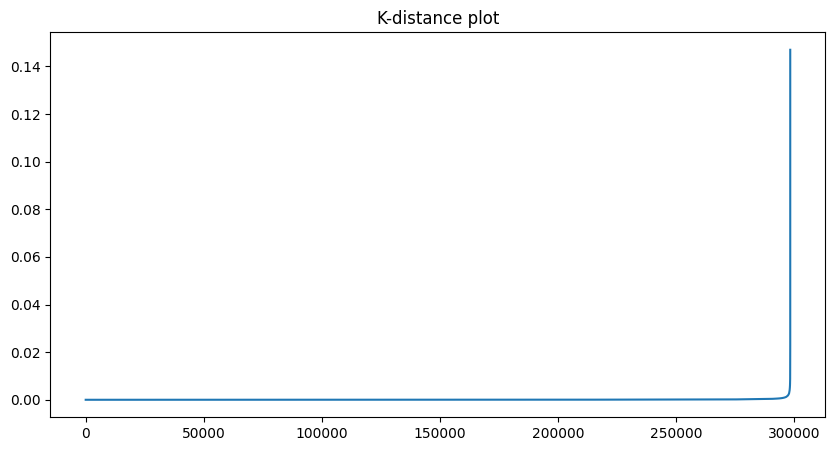

In [50]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

coords = parking_df[
    ["latitude","longitude"]
].dropna()

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(coords)

distances, indices = neighbors_fit.kneighbors(coords)

distances = np.sort(distances[:,4])

plt.figure(figsize=(10,5))
plt.plot(distances)
plt.title("K-distance plot")
plt.show()